In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from Pcm import find_model
import globals as gl
import matplotlib.patches as patches
import rsatoolbox as rsa
from rdms import D_to_rdm
import matplotlib.gridspec as gridspec
import PcmPy as pcm
from scipy.stats import ttest_1samp
import pickle
from Plot import add_colorbar, set_spines_and_ticks_width, save_figure_incremental

plt.style.use('default')

In [4]:
experiment = 'smp2'

R_between = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'corr_xval.plan_vs_exec.between_block.npy'))

N = R_between.shape[0]
noise_ceiling = np.diagonal(R_between, axis1=1, axis2=2)[:,:8]
noise_ceiling_mean = noise_ceiling.mean(axis=0)
noise_ceiling_err = noise_ceiling.std(axis=0) / np.sqrt(N)

exec_index = R_between[:, :, 8:12].mean(axis=-1)[:,:8]
exec_index_mean = exec_index.mean(axis=0)
exec_index_err = exec_index.std(axis=0) / np.sqrt(N)

exec_ring = R_between[:, :, 12:].mean(axis=-1)[:,:8]
exec_ring_mean = exec_ring.mean(axis=0)
exec_ring_err = exec_ring.std(axis=0) / np.sqrt(N)

fig, axs = plt.subplots(1, 2, figsize=(8, 6), width_ratios=(2, .8), constrained_layout=True)

vmin, vmax = 0, 1

R_between_mean = R_between.mean(axis=0)
cax = axs[0].imshow(R_between_mean, vmin=vmin, vmax=vmax)

for i in range(8):
    rect = patches.Rectangle((i - 0.5, i - 0.5), 1, 1, linewidth=2,
                     edgecolor='grey', facecolor='none', zorder=1e6)
    axs[0].add_patch(rect)

rect = patches.Rectangle((8 - .5, -.5), 4, 8, linewidth=2,
                     edgecolor='darkviolet', facecolor='none',)
axs[0].add_patch(rect)
rect = patches.Rectangle((12 - .5, -.5), 4, 8, linewidth=2,
                     edgecolor='orange', facecolor='none',)
axs[0].add_patch(rect)

ticklabels_plan = ['planning,'+i for i in list(gl.regressor_mapping.keys())[5:13]]
ticklabels_execution = ['execution,'+i for i in list(gl.regressor_mapping.keys())[5:13]]
ticklabels = ticklabels_plan + ticklabels_execution

axs[1].plot(ticklabels_plan,noise_ceiling_mean, color='grey', label='noise ceiling')
axs[1].fill_between(ticklabels_plan,noise_ceiling_mean-noise_ceiling_err, noise_ceiling_mean+noise_ceiling_err, color='grey', alpha=1, ls='-.', lw=.8, facecolor='none')
axs[1].plot(ticklabels_plan,exec_index_mean, color='darkviolet', label='execution index')
axs[1].fill_between(ticklabels_plan,exec_index_mean-exec_index_err, exec_index_mean+exec_index_err, color='darkviolet', alpha=.2, lw=0)
axs[1].plot(ticklabels_plan,exec_ring_mean, color='orange', label='execution ring')
axs[1].fill_between(ticklabels_plan,exec_ring_mean-exec_ring_err, exec_ring_mean+exec_ring_err, color='orange', alpha=.2, lw=0)

axs[0].set_xticks(np.arange(len(ticklabels)))
axs[0].set_yticks(np.arange(len(ticklabels)))
axs[0].set_xticklabels(ticklabels, rotation=60, ha='right')
axs[0].set_yticklabels(ticklabels,)

axs[1].set_xticks(np.arange(len(ticklabels_plan)))
axs[1].set_xticklabels(ticklabels_plan, rotation=60, ha='right')
axs[1].set_yticks([0, .1, .2, .3])
axs[1].spines[['top', 'right']].set_visible(False)
axs[1].spines[['bottom',]].set_bounds([0, 7])
axs[1].spines[['left',]].set_bounds([0, .3])

axs[1].axhline(0, color='k', lw=.8)
axs[1].axvline(3.5, ymax=.3,color='k', lw=.8)
axs[1].set_ylabel("Pearson's r")
axs[1].legend(loc='lower center', bbox_to_anchor=(0.5, .9))

set_spines_and_ticks_width(axs[1], spine_width=1.5,spine_sides=('bottom','left'), tick_width=1.5,axes=('x', 'y'),which='both')

add_colorbar(fig, axs[0], cax, orientation='horizontal', anchor=(.5, 0), label="Pearson's r")

fig.suptitle('Cross-validated correlation between force patterns during planning and execution')
# fig.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/cifs/diedrichsen/data/SensoriMotorPrediction/smp2/pcm/M.force.plan.p'

Text(0.5, 0.98, 'Squared distance between force patterns (planning)')

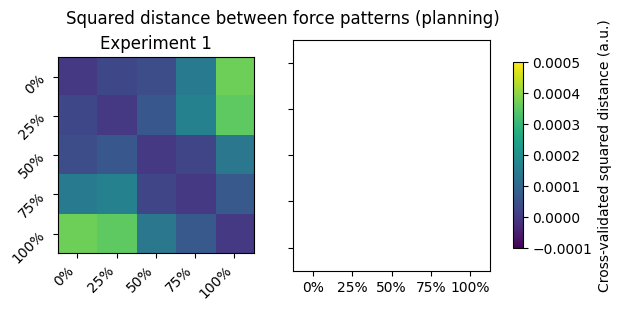

In [7]:
experiment = 'smp2'

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir,  'M.force.plan.p'), 'rb')
M = pickle.load(f)

D, name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G))
        name.append(m.name)

fig, axs = plt.subplots(1, len(D), sharex=True, sharey=True, figsize=(8, 2.5))

for ax, d, n in zip(axs, D, name ):
    ax.imshow(d, )
    ax.set_title(n)

    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')
    ax.set_yticks(np.arange(5))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')

fig.suptitle('Planning models')

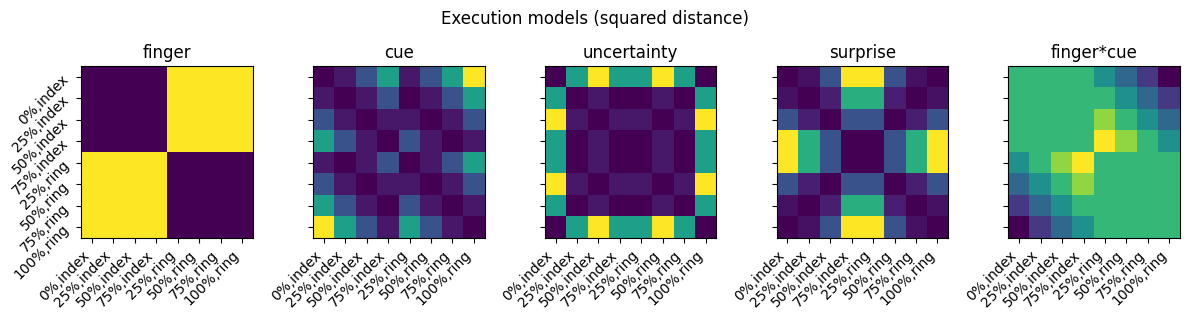

In [4]:
experiment = 'smp2'

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir,  'M.force.exec.p'), 'rb')
M = pickle.load(f)

vmin, vmax=-4, 4

D, name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G))
        name.append(m.name)
    if isinstance(m, pcm.FeatureModel):
        G = m.Ac[0] @ m.Ac[-1].T
        D.append(pcm.G_to_dist(G))
        name.append('finger*cue')

fig, axs = plt.subplots(1, len(D), sharex=True, sharey=True, figsize=(12, 3))

for ax, d, n in zip(axs, D, name ):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    ax.imshow(d, )
    ax.set_title(n)

    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')

fig.suptitle('Execution models (squared distance)')
fig.tight_layout()

Text(0.5, 0.98, 'Squared distance between force patterns (planning)')

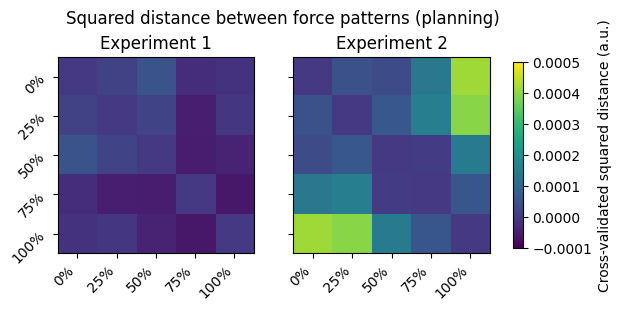

In [5]:
experiment = ['smp0', 'smp2']

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(6, 3))

vmin, vmax = -.0001, .0005

for ax, exp in zip(axs, experiment):
    G_obs = np.load(os.path.join(gl.baseDir, exp, gl.pcmDir, 'G_obs.force.plan.npy'))
    D = np.zeros_like(G_obs)
    for g, G in enumerate(G_obs):
        D[g] = pcm.G_to_dist(G)

    Dv = np.triu(D, k=1)

    cond = list(gl.regressor_mapping.keys())[:5]

    cax = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(cond)))
    ax.set_yticks(np.arange(len(cond)))
    ax.set_xticklabels(cond, rotation=45, ha='right')
    ax.set_yticklabels(cond, rotation=45, ha='right')

    ax.set_title(f'Experiment {experiment.index(exp) + 1}')

cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.02)
cbar.set_label('Cross-validated squared distance (a.u.)')

fig.suptitle(f'Squared distance between force patterns (planning)')

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/rdms force_3.svg


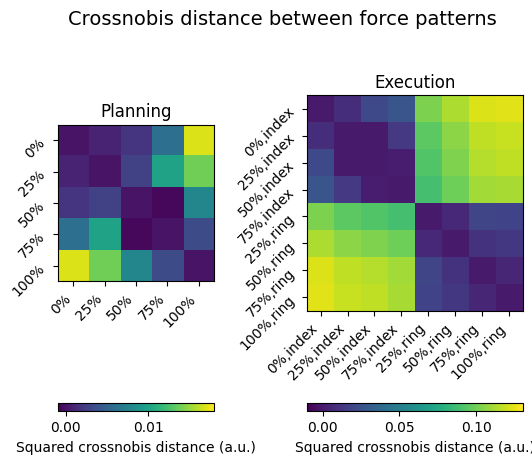

In [6]:
experiment = 'smp2'
epoch1 = 'plan'
epoch2 = 'exec'

def get_D(epoch):
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.force.{epoch}.npy'))
    D = np.zeros_like(G_obs)
    for g, G in enumerate(G_obs):
        D[g] = pcm.G_to_dist(G)
    D = np.sign(D) * np.sqrt(np.abs(D))
    return D.mean(axis=0)

fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1.375], height_ratios=[1, 4, 1], wspace=0.5)

# Left axes (centered vertically)
cond = list(gl.regressor_mapping.keys())[:5]
vmin, vmax = -.001, .018
ax1 = fig.add_subplot(gs[1, 0])
D1 = get_D(epoch1)
im1 = ax1.imshow(D1, vmin=vmin, vmax=vmax)
ax1.set_title('Planning')
ax1.set_xticks(np.arange(len(cond)))
ax1.set_yticks(np.arange(len(cond)))
ax1.set_xticklabels(cond, rotation=45, ha='right')
ax1.set_yticklabels(cond, rotation=45, ha='right')

# Right axes
cond = list(gl.regressor_mapping.keys())[5:13]
vmin, vmax = -.01, .13
ax2 = fig.add_subplot(gs[:, 1])
D2 = get_D(epoch2)
im2 = ax2.imshow(D2, vmin=vmin, vmax=vmax)
ax2.set_title('Execution')
ax2.set_xticks(np.arange(len(cond)))
ax2.set_yticks(np.arange(len(cond)))
ax2.set_xticklabels(cond, rotation=45, ha='right')
ax2.set_yticklabels(cond, rotation=45, ha='right')

# Get axes positions
pos1 = ax1.get_position()
pos2 = ax2.get_position()

# Use the same y-position for both colorbars
shared_y = min(pos1.y0, pos2.y0) - 0.25
cb_height = 0.02

cb1_ax = fig.add_axes([pos1.x0, shared_y, pos1.width, cb_height])
cb2_ax = fig.add_axes([pos2.x0, shared_y, pos2.width, cb_height])

cb1 = fig.colorbar(im1, cax=cb1_ax, orientation='horizontal')
cb1.set_label('Squared crossnobis distance (a.u.)')

cb2 = fig.colorbar(im2, cax=cb2_ax, orientation='horizontal')
cb2.set_label('Squared crossnobis distance (a.u.)')

fig.suptitle('Crossnobis distance between force patterns', fontsize=14)
plt.tight_layout(rect=[0, 0.14, 1, 0.93])  # Leave space for colorbars + title

save_figure_incremental(fig, 'rdms force')
plt.show()

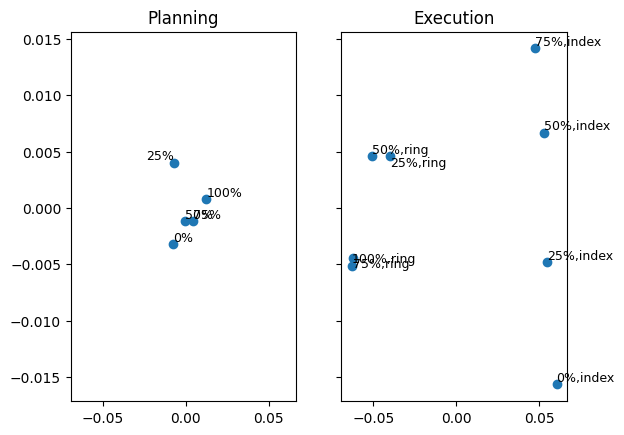

In [7]:
experiment = 'smp2'
epochs = ['plan', 'exec']

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True)

for e, epoch in enumerate(epochs):
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.force.{epoch}.npy'))
    W, Glam = pcm.classical_mds(G_obs.mean(axis=0))
    axs[e].scatter(W[:, 0], W[:, 1],)

    if epoch == 'plan':
        title = 'Planning'
        labels = list(gl.regressor_mapping.keys())[:5]
    elif epoch == 'exec':
        title = 'Execution'
        labels = list(gl.regressor_mapping.keys())[5:13]

    axs[e].set_title(title)
    texts = []
    for i, label in enumerate(labels):
        ha='left'
        va='bottom'
        if label=='25%':
            ha='right'
        if label=='25%,ring':
            va='top'
        if label=='75%,ring':
            va='top'
        axs[e].text(W[i, 0], W[i, 1], label, fontsize=9, ha=ha, va=va)


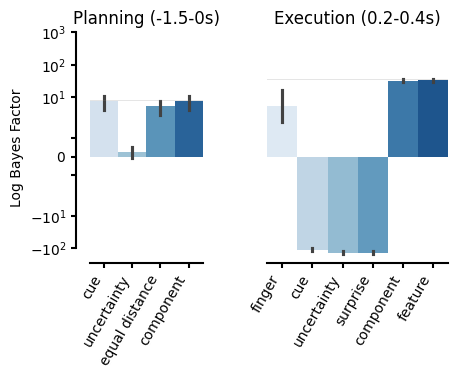

In [8]:
epochs = ['plan', 'exec',]
experiment = 'smp2'

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 3), sharey=True, gridspec_kw={'width_ratios': [4, 6]})

for r, epoch in enumerate(epochs):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.force.{epoch}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.force.{epoch}.p'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Blues',
                    errorbar='se')
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.spines[['left',]].set_bounds(-10**2, 10**3)
    ax.set_yticks([-10**2, -10, 0, 10, 10**2, 10**3])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        ax.set_xlim(-1, 4)
        ax.spines[['bottom',]].set_bounds(-.5, 3.5)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
        ax.set_title('Planning (-1.5-0s)')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        ax.set_xlim(-1, 6)
        ax.spines[['bottom',]].set_bounds(-.5, 5.5)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')
        ax.set_title('Execution (0.2-0.4s)')

plt.show()

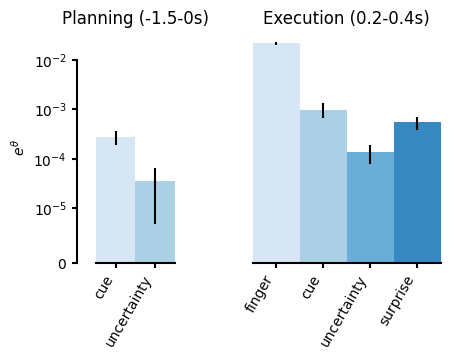

In [9]:
epochs = ['plan', 'exec',]
experiment = 'smp2'

components = (['cue','uncertainty'], ['finger', 'cue', 'uncertainty', 'surprise'])

fig, axs = plt.subplots(1, len(epochs),sharey=True, figsize=(5, 3), gridspec_kw={'width_ratios': [2, 4]})

colors = sns.color_palette("Blues", n_colors=5)[:4]

for r, epoch in enumerate(epochs):

    M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.force.{epoch}.p'), 'component')
    n_param = M.n_param

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.force.{epoch}.p'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components[r], theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_yscale('symlog', linthresh=1e-5)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        axs[r].set_title('Planning (-1.5-0s)')
        axs[r].spines[['bottom',]].set_bounds(-.5, 1.5)
        axs[r].spines[['left',]].set_bounds(0, 10**-2)
        axs[r].set_xlim(-1, 2)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        axs[r].set_title('Execution (0.2-0.4s)')
        axs[r].spines[['bottom',]].set_bounds(-.5, 3.5)
        axs[r].set_xlim(-1, 4)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()



In [13]:
experiment = 'smp2'

features = ['finger', 'cue', 'uncertainty', 'surprise', 'finger*cue']

fig, axs = plt.subplots(figsize=(3, 4))

colors = sns.color_palette("Reds", n_colors=5)[:4] +  [(0, 0, 0)]

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.force.exec.p'), 'feature')
n_param = M.n_param

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.force.exec.p'), "rb")
theta = np.exp(pickle.load(f)[idx][:n_param])

theta_avg = theta.mean(axis=1)
theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

axs.bar(features, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
axs.set_xticks(axs.get_xticks())
axs.set_xticklabels(axs.get_xticklabels(), rotation=60, ha='right')
# axs.set_yscale('symlog', linthresh=1e-5)

axs.set_ylabel(r'$\theta$')
axs.spines[['top', 'right',]].set_visible(False)
axs.set_title('Execution (0.2-0.4s)')
axs.spines[['bottom',]].set_bounds(-.5, 4.5)
# axs.set_ylim([.9, 1.2])
axs.spines[['left',]].set_bounds(0, 8)
axs.set_xlim(-1, 5)
axs.set_yscale('log')
set_spines_and_ticks_width(axs, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')


plt.show()